# Benchmark GARCH

## Overview

This notebook implements the standard GARCH benchmark used to forecast Bitcoin realized variance without regime-aware features. It fits rolling GARCH models to historical Bitcoin log returns and uses the resulting one-step-ahead variance forecasts as an econometric baseline.

The purpose of the notebook is to provide a regime-unaware comparison point for the project's machine learning and regime-aware volatility models. The object being forecast is next-day log realized variance, with forecasts also exponentiated back to the realized variance scale for QLIKE evaluation and visual comparison.

The notebook is structured as follows:

1. Load the two-regime modelling dataset and construct log realized variance.
2. Clean the data, restrict the sample to the modelling period, and split it into training, evaluation, and test sets.
3. Define rolling GARCH forecasting, RMSE, and QLIKE evaluation utilities.
4. Tune GARCH lag orders on the evaluation window using a 365-day rolling training window.
5. Select the best GARCH specification and run the final out-of-sample test forecast.
6. Plot actual versus predicted realized variance, plot forecast errors, and export the test predictions to `garch.csv`.


In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv('../data/df_with_2regimes.csv')
df["date"] = pd.to_datetime(df["date"])
df.head()
len(df)
df['log_realized_variance'] = np.log(df['realized_variance'])
df.isna().sum()
df = df.dropna()

# start from 2017-07-13
df = df[df["date"] >= "2017-07-13"]


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3125 entries, 393 to 3517
Data columns (total 38 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        3125 non-null   datetime64[ns]
 1   log_return                                  3125 non-null   float64       
 2   realized_variance                           3125 non-null   float64       
 3   realized_volatility                         3125 non-null   float64       
 4   gtrend_pct_change                           3125 non-null   float64       
 5   blockchain_diff_log_n_transactions          3125 non-null   float64       
 6   blockchain_diff_log_transaction_fee_usd     3125 non-null   float64       
 7   blockchain_diff_log_n_unique_addresses      3125 non-null   float64       
 8   blockchain_diff_log_transaction_volume_usd  3125 non-null   float64       
 9   log_vo

In [21]:
df['log_return'].describe()

count    3125.000000
mean        0.001119
std         0.036546
min        -0.491226
25%        -0.014205
50%         0.000525
75%         0.016399
max         0.240606
Name: log_return, dtype: float64

In [4]:
n = len(df)

train_size = int(n * 0.60)
eval_size  = int(n * 0.25)

train_start_idx = 0
train_end_idx   = train_size

eval_start_idx = train_end_idx
eval_end_idx   = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx   = n

train_df = df.iloc[train_start_idx:train_end_idx].copy()
eval_df  = df.iloc[eval_start_idx:eval_end_idx].copy() 
test_df  = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set: {len(train_df)} rows")
print(f"Eval set:  {len(eval_df)} rows")
print(f"Test set:  {len(test_df)} rows")

Train set: 1875 rows
Eval set:  781 rows
Test set:  469 rows


In [32]:
def rolling_garch_benchmark_eval(
    df_full,
    start_idx,
    end_idx,
    return_col="log_return",
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    p=1,
    q=1,
    mean="constant",
    vol="GARCH",
    dist="t",
    min_obs=200
):
    results = []

    for t in range(start_idx - 1, end_idx - 1):
        train_start = max(0, t - rolling_window + 1)
        train_end = t + 1

        train_slice = df_full.iloc[train_start:train_end].copy()
        train_returns = train_slice[return_col].dropna()
        next_row = df_full.iloc[t + 1]

        if len(train_returns) < min_obs:
            results.append({
                date_col: next_row[date_col],
                "actual_var": next_row[realized_var_col],
                "var_garch_bench": np.nan
            })
            continue

        fitted = fit_garch_benchmark(
            train_returns,
            p=p,
            q=q,
            mean=mean,
            vol=vol,
            dist=dist
        )

        log_var_forecast = one_step_log_variance_forecast(fitted)

        results.append({
            date_col: next_row[date_col],
            "actual_var": next_row[realized_var_col],
            "var_garch_bench": log_var_forecast
        })

    return pd.DataFrame(results)

def fit_garch_benchmark(returns, p=1, q=1, mean="constant", vol="GARCH", dist="t"):
    returns = pd.Series(returns).dropna().astype(float)

    if len(returns) < 200:
        return None

    try:
        am = arch_model(
            returns * 100.0,
            mean=mean,
            vol=vol,
            p=p,
            q=q,
            dist=dist
        )
        res = am.fit(disp="off")
        return res
    except Exception as e:
        print("GARCH fit error:", e)
        return None


def one_step_log_variance_forecast(fitted_model, eps=1e-12):
    if fitted_model is None:
        return np.nan

    try:
        fcast = fitted_model.forecast(horizon=1, reindex=False)
        var_scaled = fcast.variance.values[-1, 0]
        var_orig = var_scaled / (100.0 ** 2)
        return np.log(var_orig + eps)
    except Exception as e:
        print("Forecast error:", e)
        return np.nan

In [33]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0) & (y_pred > 0)
    if mask.sum() == 0:
        return np.nan

    yt = y_true[mask]
    yp = y_pred[mask]

    print(f"y_true range: {y_true.min():.2e} to {y_true.max():.2e}")
    print(f"y_pred range: {y_pred.min():.2e} to {y_pred.max():.2e}")
    print(f"log term mean: {np.log(yp).mean():.4f}")
    print(f"ratio term mean: {(yt/yp).mean():.4f}")

    return np.mean(np.log(yp + eps) + yt / (yp + eps))

def qlike2(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike


In [34]:
from arch import arch_model
from itertools import product

In [36]:
garch_grid = {
    "p": [1, 2, 3],
    "q": [1, 2,3]
}


garch_param_grid = []
for p, q, in product(
    garch_grid["p"],
    garch_grid["q"]
):
    garch_param_grid.append({
        "p": p,
        "q": q
    })

garch_results = []

for i, params in enumerate(garch_param_grid, 1):
    p = params["p"]
    q = params["q"]

    print(f"\n[{i}/{len(garch_param_grid)}] Testing GARCH: {params}")

    try:
        res = rolling_garch_benchmark_eval(
            df_full=df,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            return_col="log_return",
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            p=p,
            q=q,
            mean="constant",
            vol="GARCH",
            dist="t",
            min_obs=200
        )

        valid_mask = (
            np.isfinite(res["actual_var"]) &
            np.isfinite(res["var_garch_bench"])
        )

        y_true = res.loc[valid_mask, "actual_var"]
        y_pred = res.loc[valid_mask, "var_garch_bench"]

        eval_rmse = rmse(y_true, y_pred)

        eval_qlike = qlike2(
           np.exp(y_true),
           np.exp(y_pred)
        )

        n_total = len(res)
        n_valid = valid_mask.sum()

        print(f"Eval RMSE : {eval_rmse:.6f}")
        print(f"Eval QLIKE: {eval_qlike:.6f}")
        print(f"Total rows    : {n_total}")
        print(f"Valid eval obs: {n_valid}")

        garch_results.append({
            "p": p,
            "q": q,
            "eval_rmse": eval_rmse,
            "eval_qlike": eval_qlike,
            "n_total": n_total,
            "n_valid": n_valid,
            "results_df": res
        })

    except Exception as e:
        print(f"Failed for p={p}, q={q}: {e}")
        



[1/9] Testing GARCH: {'p': 1, 'q': 1}
Eval RMSE : 1.621514
Eval QLIKE: 0.739109
Total rows    : 781
Valid eval obs: 781

[2/9] Testing GARCH: {'p': 1, 'q': 2}
Eval RMSE : 1.592517
Eval QLIKE: 0.721728
Total rows    : 781
Valid eval obs: 781

[3/9] Testing GARCH: {'p': 1, 'q': 3}
Eval RMSE : 1.483419
Eval QLIKE: 0.653385
Total rows    : 781
Valid eval obs: 781

[4/9] Testing GARCH: {'p': 2, 'q': 1}
Eval RMSE : 1.630729
Eval QLIKE: 0.746695
Total rows    : 781
Valid eval obs: 781

[5/9] Testing GARCH: {'p': 2, 'q': 2}
Eval RMSE : 1.584988
Eval QLIKE: 0.716886
Total rows    : 781
Valid eval obs: 781

[6/9] Testing GARCH: {'p': 2, 'q': 3}
Eval RMSE : 1.475345
Eval QLIKE: 0.647135
Total rows    : 781
Valid eval obs: 781

[7/9] Testing GARCH: {'p': 3, 'q': 1}
Eval RMSE : 1.615100
Eval QLIKE: 0.736644
Total rows    : 781
Valid eval obs: 781

[8/9] Testing GARCH: {'p': 3, 'q': 2}
Eval RMSE : 1.593114
Eval QLIKE: 0.721923
Total rows    : 781
Valid eval obs: 781

[9/9] Testing GARCH: {'p': 3, '

In [37]:
garch_results_df = pd.DataFrame(garch_results).sort_values("eval_qlike")
print(garch_results_df.head())

   p  q  eval_rmse  eval_qlike  n_total  n_valid  \
5  2  3   1.475345    0.647135      781      781   
2  1  3   1.483419    0.653385      781      781   
8  3  3   1.486001    0.655508      781      781   
4  2  2   1.584988    0.716886      781      781   
1  1  2   1.592517    0.721728      781      781   

                                          results_df  
5            date  actual_var  var_garch_bench
0 ...  
2            date  actual_var  var_garch_bench
0 ...  
8            date  actual_var  var_garch_bench
0 ...  
4            date  actual_var  var_garch_bench
0 ...  
1            date  actual_var  var_garch_bench
0 ...  


In [38]:
best_garch_params = garch_results_df.iloc[0].to_dict()

best_p = int(best_garch_params["p"])
best_q = int(best_garch_params["q"])

best_p, best_q


(2, 3)

#### out of sample test

In [41]:
test_garch = rolling_garch_benchmark_eval(
    df_full=df,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    return_col="log_return",
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    p=best_p,
    q=best_q,
    mean="constant",
    vol="GARCH",
    dist="t",
    min_obs=200
)

test_rmse = rmse(test_garch["actual_var"], test_garch["var_garch_bench"])
test_qlike = qlike2(
           np.exp(test_garch["actual_var"]),
           np.exp(test_garch["var_garch_bench"])
        )

print("Final Test RMSE :", test_rmse)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_garch["var_garch_bench"].notna().sum())

Final Test RMSE : 1.0875121507150856
Final Test QLIKE: 0.43333737612205614
Number of test forecasts: 469


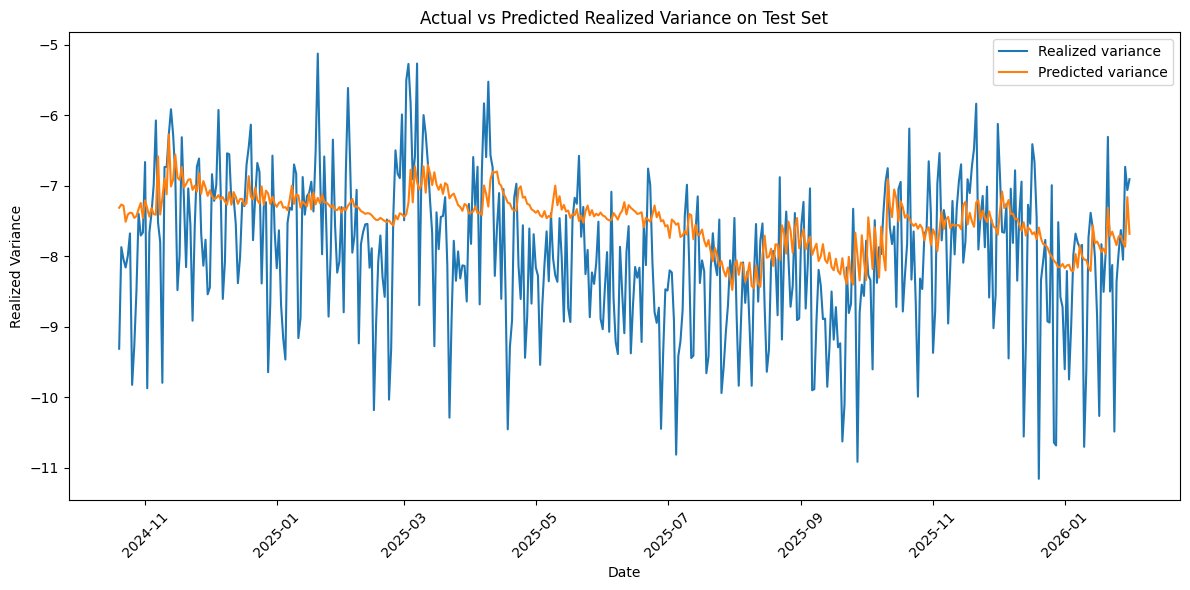

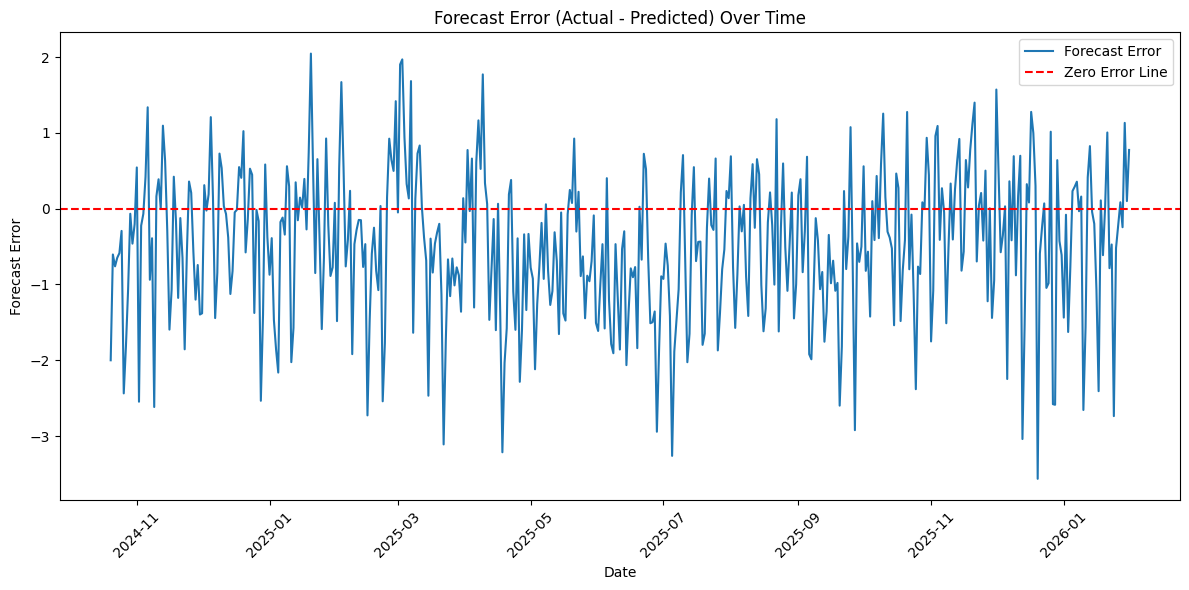

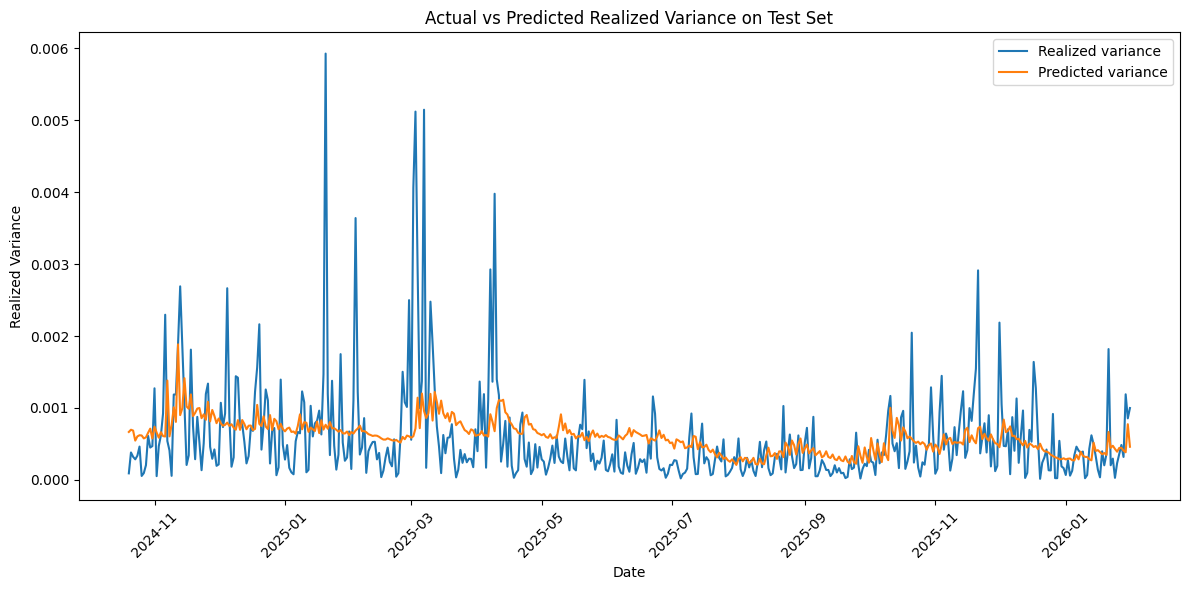

In [43]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_garch['date'] = pd.to_datetime(test_garch['date'])
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], test_garch["actual_var"], label="Realized variance")
plt.plot(test_garch["date"], test_garch["var_garch_bench"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_garch['date'] = pd.to_datetime(test_garch['date'])
test_garch['error'] = test_garch["actual_var"] - test_garch["var_garch_bench"]
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], test_garch["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_garch['date'] = pd.to_datetime(test_garch['date'])
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], np.exp(test_garch["actual_var"]), label="Realized variance")
plt.plot(test_garch["date"], np.exp(test_garch["var_garch_bench"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [44]:
# save final results and export test predictions
test_garch.to_csv("garch.csv", index=False)

In [45]:
test_garch.head()

,date,actual_var,var_garch_bench,error
0,2024-10-20,-9.314845,-7.314578,-2.000267
1,2024-10-21,-7.873473,-7.268976,-0.604497
2,2024-10-22,-8.046507,-7.285733,-0.760775
3,2024-10-23,-8.161787,-7.513165,-0.648622
4,2024-10-24,-7.997675,-7.411257,-0.586418
